# Exploration des Données (EDA) - Prédiction du Churn Telco
## Notebook 01 : Analyse Exploratoire des Données

---

##  Résumé Exécutif

| Élément | Description |
|--------|-------------|
| **Projet** | Modèle de Scoring du Risque de Churn Client |
| **Objectif** | Prédire la probabilité de résiliation pour chaque client TelcoWave |
| **Métier** | Télécommunications (Mobile + Fibre) |
| **Étape** | Phase 1 : Exploration et Compréhension des Données |
| **Sortie attendue** | Insights clés, données nettoyées, features identifiées |

---

##  Contexte et Objectifs

### Enjeu Métier
TelcoWave souhaite **anticiper les départs de clients** (churn) pour déployer des actions de rétention ciblées et optimiser son ROI marketing. Un score de probabilité de churn par client permettra de :
-  Identifier les clients à risque
- Automatiser les actions de rétention
- Optimiser le budget de retention

### Objectifs de ce Notebook
1. **Charger et valider** les données brutes
2. **Analyser la structure** : types, dimensions, qualité
3. **Comprendre la cible** : distribution du churn
4. **Explorer les variables** : patterns, corrélations, anomalies
5. **Générer des insights** : bases solides pour la modélisation

In [1]:
#!/usr/bin/env python3
"""
Configuration de l'environnement - EDA Churn Telco
==================================================
Ce script initialise tous les imports et configurations nécessaires
pour l'exploration et l'analyse des données de churn.
"""

import os

# 1. MANIPULATION ET ANALYSE DES DONNÉES
import pandas as pd
import numpy as np
from typing import List, Tuple

# 2. STATISTIQUES ET ANALYSE NUMÉRIQUE
import scipy.stats as ss
from scipy import stats

# 3. VISUALISATION
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

---

## Questions Clés à Répondre

| Question | Pourquoi ? | Impact |
|----------|----------|--------|
| **Quelle est la taille du dataset ?** | Évaluer si on a assez de données | Risque de surapprentissage ? |
| **Y a-t-il des valeurs manquantes ?** | Décider comment les traiter | Perte de données vs imputation |
| **Comment est répartie la cible (Churn) ?** | Comprendre le déséquilibre | Stratégie de balancing |
| **Quelles variables influencent le churn ?** | Identifier les vrais prédicteurs | Sélection des features |
| **Y a-t-il des outliers ?** | Nettoyer les données aberrantes | Robustesse du modèle |

---

In [2]:
#Affichage du répertoire de travail actuel
os.getcwd()

'c:\\Users\\juber\\Documents\\Projet_Classsification_Binaire_Churn_Telco\\notebooks'

---

#  ÉTAPE 1 : Chargement & Inspection des Données Brutes

## Objectif
Charger les données et obtenir une **première vue** de leur structure, dimensions et composition.

### Questions à Répondre
-  Quel est le volume du dataset ? (lignes / colonnes)
-  Comment sont structurées les données ?
-  Les types de colonnes sont-ils cohérents ?
-  Y a-t-il des problèmes évidents ?


In [3]:
# 1.1 CHARGEMENT DU DATASET

# Chemin du fichier de données
df = "..\\data\\Telco-Customer-Churn.csv"

# Chargement dans un DataFrame pandas
df = pd.read_csv(df)

# 1.2 DIMENSIONS DU DATASET
n_rows, n_cols = df.shape

print("=" * 70)
print(" DIMENSIONS DU DATASET")
print("=" * 70)
print(f"✓ Observations (lignes) : {n_rows:,}")
print(f"✓ Variables (colonnes)  : {n_cols}")
print(f"✓ Total de cellules     : {n_rows * n_cols:,}")
print("=" * 70)


 DIMENSIONS DU DATASET
✓ Observations (lignes) : 7,043
✓ Variables (colonnes)  : 21
✓ Total de cellules     : 147,903


---

## 1.2 - Aperçu des Données

### À Observer
- Noms des colonnes : sont-elles explicites ?
- Types de valeurs : nombres, texte, formats bizarres ?
- Distribution de la cible (`Churn`) : équilibrée ?
- Anomalies visuelles : valeurs étranges, espaces vides ?

In [4]:
# Affichage des premières lignes pour inspection visuelle
print("\n APERÇU DES 5 PREMIÈRES LIGNES\n")
df.head()



 APERÇU DES 5 PREMIÈRES LIGNES



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---

## 1.3 - Vérification des Doublons

### But
Identifier les lignes dupliquées dans le dataset :
- Doublons exacts (tous les colonnes identiques)
- Doublons partiels (on peut exclure certaines colonnes)
- Impact sur la qualité des données

In [5]:
# Vérification des doublons
print("\n" + "="*70)
print(" VÉRIFICATION DES DOUBLONS")
print("="*70 + "\n")

# Doublons exacts
n_doublons_exacts = df.duplicated().sum()
pct_doublons_exacts = (n_doublons_exacts / len(df)) * 100

print(f"✓ Doublons exacts (toutes colonnes)                : {n_doublons_exacts} ({pct_doublons_exacts:.2f}%)")

# Doublons sans tenir compte d'une colonne (CustomerID supposé unique)
if 'customerID' in df.columns:
    n_doublons_no_id = df.duplicated(subset=df.columns.difference(['customerID'])).sum()
    pct_doublons_no_id = (n_doublons_no_id / len(df)) * 100
    print(f"✓ Doublons (toutes colonnes sauf customerID)    : {n_doublons_no_id} ({pct_doublons_no_id:.2f}%)")

print("\n" + "="*70)


 VÉRIFICATION DES DOUBLONS

✓ Doublons exacts (toutes colonnes)                : 0 (0.00%)
✓ Doublons (toutes colonnes sauf customerID)    : 22 (0.31%)



---

## 1.4 - Valeurs Manquantes

### Analyse des Données Incomplètes
- Identifier les colonnes avec des valeurs manquantes
- Quantifier l'impact (nombre et pourcentage)
- Déterminer les stratégies de gestion (suppression, imputation, etc.)

In [6]:
# Analyse des valeurs manquantes
print("\n" + "="*70)
print(" ANALYSE DES VALEURS MANQUANTES")
print("="*70 + "\n")

# Résumé des valeurs manquantes
missing_data = pd.DataFrame({
    'Colonne': df.columns,
    'Manquantes': df.isnull().sum().values,
    'Pourcentage': (df.isnull().sum().values / len(df) * 100).round(2)
})

# Filtrer les colonnes avec des manquantes
missing_data_filtered = missing_data[missing_data['Manquantes'] > 0].sort_values('Manquantes', ascending=False)

if len(missing_data_filtered) > 0:
    print("Colonnes avec valeurs manquantes :\n")
    display(missing_data_filtered.reset_index(drop=True))
else:
    print("✓ Aucune valeur manquante détectée !")

print(f"\n✓ Total de cellules manquantes        : {df.isnull().sum().sum()}")
print(f"✓ Pourcentage global de complétude    : {(1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.2f}%")
print("\n" + "="*70)


 ANALYSE DES VALEURS MANQUANTES

✓ Aucune valeur manquante détectée !

✓ Total de cellules manquantes        : 0
✓ Pourcentage global de complétude    : 100.00%



---

## 1.5 - Types de Données & Complétude

### À Observer
- **Colonne 'Churn'** : valeurs `Yes`/`No` ou `0`/`1` ? Cohérent ?
- **Types `object`** : lesquels ? (peuvent être catégoriques ou texte)
- **Valeurs manquantes** : par colonne, par type
- **Int64 vs float64** : numériques entiers ou décimales ?

In [7]:
# Affichage détaillé des informations du dataframe
print("\n" + "="*70)
print(" INFORMATIONS SUR LES COLONNES & TYPES DE DONNÉES")
print("="*70 + "\n")

# Créer un rapport personnalisé
info_data = {
    'Colonne': df.columns,
    'Type': df.dtypes.values,
    'Non-Null Count': df.isnull().sum().values,
    'Null %': (df.isnull().sum().values / len(df) * 100).round(2)
}

info_df = pd.DataFrame(info_data)
display(info_df)

print("\n ANALYSE DES TYPES :")
print(f"   • Variables numériques (int/float)  : {df.select_dtypes(include=[np.number]).shape[1]}")
print(f"   • Variables catégoriques (object)   : {df.select_dtypes(include=['object']).shape[1]}")
print(f"   • Valeurs manquantes totales        : {df.isnull().sum().sum()}")
print(f"   • Pourcentage de complétude         : {(1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.2f}%")


 INFORMATIONS SUR LES COLONNES & TYPES DE DONNÉES



,Colonne,Type,Non-Null Count,Null %
0,customerID,object,0,0.0
1,gender,object,0,0.0
2,SeniorCitizen,int64,0,0.0
3,Partner,object,0,0.0
4,Dependents,object,0,0.0
5,tenure,int64,0,0.0
6,PhoneService,object,0,0.0
7,MultipleLines,object,0,0.0
8,InternetService,object,0,0.0
9,OnlineSecurity,object,0,0.0



 ANALYSE DES TYPES :
   • Variables numériques (int/float)  : 3
   • Variables catégoriques (object)   : 18
   • Valeurs manquantes totales        : 0
   • Pourcentage de complétude         : 100.00%


---

## 1.6 - Statistiques Descriptives des Variables Numériques

### Interprétation des Statistiques

| Métrique | Signification | À Chercher |
|----------|--------------|-----------|
| **count** | Nombre de valeurs non-nulles | Révèle des manquants |
| **mean** | Moyenne arithmétique | Tendance centrale |
| **std** | Écart-type | Dispersion des données |
| **min / max** | Valeurs extrêmes | Outliers potentiels |
| **25%, 50%, 75%** | Quartiles | Asymétrie de distribution |

In [8]:
# Statistiques descriptives pour les variables numériques
print("\n" + "="*70)
print(" STATISTIQUES DESCRIPTIVES - VARIABLES NUMÉRIQUES")
print("="*70 + "\n")

df.describe()



 STATISTIQUES DESCRIPTIVES - VARIABLES NUMÉRIQUES



,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


---

## 1.7 - Échantillonnage Aléatoire

### Objectif
Vérifier que les données sont **cohérentes partout**, pas seulement au début du fichier.

### Approche
- `head()` : débuts du dataset (peut être trompeur)
- `sample()` : points aléatoires → représentatif
- Comparer : les anomalies se retrouvent-elles ?

### À Observer
- Cohérence générale
- Présence d'anomalies dispersées
- Validité des édges cases

In [9]:
# Affichage de 10 lignes aléatoires pour validation globale
print("\n APERÇU DE 10 LIGNES ALÉATOIRES (validation cohérence)\n")
df.sample(10)



 APERÇU DE 10 LIGNES ALÉATOIRES (validation cohérence)



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3999,5276-KQWHG,Female,1,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.60,131.65,Yes
2117,4139-DETXS,Female,0,Yes,Yes,72,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),64.45,4528,No
6509,0616-ATFGB,Male,1,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,No,Electronic check,25.05,25.05,Yes
104,3192-NQECA,Male,0,Yes,No,68,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),110.00,7611.85,Yes
5401,5124-EOGYE,Male,0,No,No,31,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.45,638.55,No
2184,4695-WJZUE,Female,1,No,No,2,Yes,Yes,Fiber optic,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,88.55,179.25,Yes
71,0731-EBJQB,Female,0,Yes,Yes,52,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Electronic check,20.40,1090.65,No
573,4710-FDUIZ,Male,0,Yes,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,One year,No,Credit card (automatic),100.30,5614.45,Yes
5741,5883-GTGVD,Male,0,No,No,19,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.95,1931.75,Yes
2858,9512-PHSMG,Female,0,Yes,No,10,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.55,252.75,No


---

## 1.8 - Stratégies de Traitement des Valeurs Manquantes

### Stratégies Décisionnelles

| Situation | Stratégie |
|-----------|-----------|
| **< 1% manquants** | Supprimer les lignes (perte négligeable) |
| **1-5% manquants** | Imputer (moyenne/médiane pour numériques, mode pour catégoriques) |
| **5-30% manquants** | Analyser le pattern, décider au cas par cas |
| **> 30% manquants** | Supprimer la colonne (non fiable) |
| **Manquants systématiques** | Créer une feature binaire "absent" |

In [10]:
# Analyse détaillée des valeurs manquantes
print("\n" + "="*70)
print(" ANALYSE DES VALEURS MANQUANTES")
print("="*70 + "\n")

missing_analysis = pd.DataFrame({
    'Colonne': df.columns,
    'Manquants': df.isnull().sum().values,
    'Manquants %': (df.isnull().sum().values / len(df) * 100).round(2),
    'Status': [' OK' if x == 0 else '⚠️  À traiter' for x in df.isnull().sum().values]
})

missing_analysis = missing_analysis[missing_analysis['Manquants'] > 0].sort_values('Manquants', ascending=False)

if len(missing_analysis) == 0:
    print(" EXCELLENT : Aucune valeur manquante détectée !")
    print("   Le dataset est complet et prêt pour la modélisation.")
else:
    print("  VALEURS MANQUANTES DÉTECTÉES :\n")
    display(missing_analysis)
    print("\n RECOMMANDATIONS :")
    for idx, row in missing_analysis.iterrows():
        pct = row['Manquants %']
        if pct < 1:
            print(f"   • {row['Colonne']} ({pct}%) : Supprimer les lignes")
        elif pct < 5:
            print(f"   • {row['Colonne']} ({pct}%) : Imputer (moyenne/médiane/mode)")
        elif pct < 30:
            print(f"   • {row['Colonne']} ({pct}%) : Analyser le pattern d'absence")
        else:
            print(f"   • {row['Colonne']} ({pct}%) : ⛔ Considérer la suppression")


 ANALYSE DES VALEURS MANQUANTES

 EXCELLENT : Aucune valeur manquante détectée !
   Le dataset est complet et prêt pour la modélisation.


---

#  ÉTAPE 2 : Analyse de la Variable Cible (CHURN)


In [11]:
# PHASE 2: ANALYSE DE LA VARIABLE CIBLE (CHURN)

# 2.1 - Comptage et vérification de la cible
print("\n" + "="*70)
print(" ANALYSE DE LA CIBLE : DISTRIBUTION DU CHURN")
print("="*70 + "\n")

# Vérifier que la cible existe
if 'Churn' not in df.columns:
    print(" ERREUR : La colonne 'Churn' n'existe pas !")
else:
    # Compter les occurrences
    churn_counts = df['Churn'].value_counts()
    churn_percentages = df['Churn'].value_counts(normalize=True) * 100
    
    # Déterminer laquelle est la classe minoritaire
    churned = churn_counts.get('Yes', 0) if 'Yes' in churn_counts.index else churn_counts.get(1, 0)
    not_churned = churn_counts.get('No', 0) if 'No' in churn_counts.index else churn_counts.get(0, 0)
    
    churn_rate = (churned / (churned + not_churned) * 100) if (churned + not_churned) > 0 else 0
    
    print(f"{'CLASSE':<20} {'COMPTE':<15} {'POURCENTAGE':<15}")
    print("-" * 50)
    for label, count in churn_counts.items():
        pct = (count / len(df)) * 100
        print(f"{str(label):<20} {count:<15} {pct:>6.2f}%")
    
    print("\n" + "="*70)
    print(f" TAUX DE CHURN : {churn_rate:.2f}%")
    print("="*70)
    
    # Diagnostic d'équilibre
    print("\n DIAGNOSTIC D'ÉQUILIBRE :\n")
    if churn_rate < 20:
        status = " TRÈS DÉSÉQUILIBRÉ"
        recommendation = "Utiliser class_weight ou SMOTE pour équilibrer"
    elif churn_rate < 40:
        status = " MOYENNEMENT DÉSÉQUILIBRÉ"
        recommendation = "Envisager le balancing ou class_weight"
    elif churn_rate < 60:
        status = " ÉQUILIBRÉ"
        recommendation = "Pas d'action urgente nécessaire"
    else:
        status = " INVERSE (plus de churn que non-churn)"
        recommendation = "Analyser le contexte métier"
    
    print(f"   Status : {status}")
    print(f"   Ratio minoritaire/majoritaire : 1:{max(churned, not_churned) / min(churned, not_churned):.2f}")
    print(f"   Recommandation : {recommendation}")


 ANALYSE DE LA CIBLE : DISTRIBUTION DU CHURN

CLASSE               COMPTE          POURCENTAGE    
--------------------------------------------------
No                   5174             73.46%
Yes                  1869             26.54%

 TAUX DE CHURN : 26.54%

 DIAGNOSTIC D'ÉQUILIBRE :

   Status :  MOYENNEMENT DÉSÉQUILIBRÉ
   Ratio minoritaire/majoritaire : 1:2.77
   Recommandation : Envisager le balancing ou class_weight


C:\Users\juber\AppData\Local\Temp\ipykernel_25284\995028134.py:62: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
c:\Users\juber\Documents\Projet_Classsification_Binaire_Churn_Telco\env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


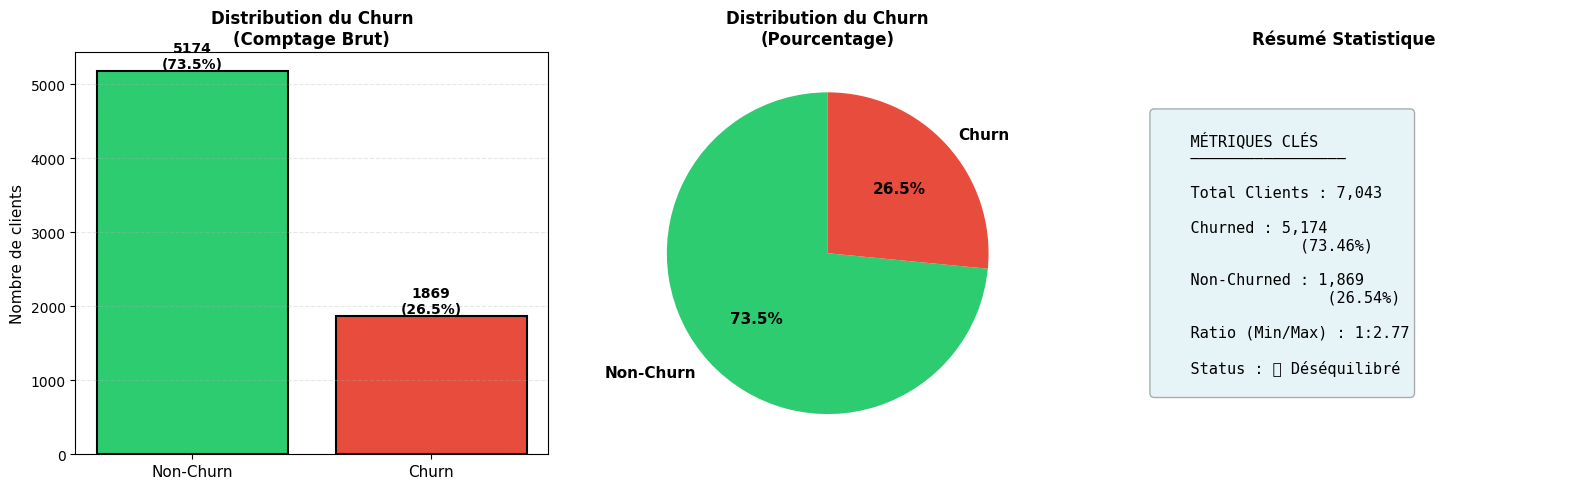

In [12]:
# 2.2 - VISUALISATIONS DE LA DISTRIBUTION DU CHURN

# Préparer les données pour les graphiques
if 'Churn' in df.columns:
    churn_counts = df['Churn'].value_counts()
    churn_pct = df['Churn'].value_counts(normalize=True) * 100
    
    # Créer les graphiques
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # --- GRAPHIQUE 1 : Bar chart avec comptages ---
    colors = ['#2ecc71', '#e74c3c']  # vert, rouge
    bars = axes[0].bar(range(len(churn_counts)), churn_counts.values, color=colors, edgecolor='black', linewidth=1.5)
    axes[0].set_title('Distribution du Churn\n(Comptage Brut)', fontsize=12, fontweight='bold')
    axes[0].set_xticks(range(len(churn_counts)))
    axes[0].set_xticklabels(['Non-Churn', 'Churn'] if 'Yes' in churn_counts.index else [0, 1], fontsize=11)
    axes[0].set_ylabel('Nombre de clients', fontsize=11)
    axes[0].grid(axis='y', alpha=0.3, linestyle='--')
    
    # Ajouter les valeurs sur les barres
    for i, (bar, value) in enumerate(zip(bars, churn_counts.values)):
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(value)}\n({churn_pct.iloc[i]:.1f}%)',
                    ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # --- GRAPHIQUE 2 : Pie chart ---
    labels = ['Non-Churn', 'Churn'] if 'Yes' in churn_counts.index else ['Class 0', 'Class 1']
    wedges, texts, autotexts = axes[1].pie(churn_counts.values, 
                                            labels=labels,
                                            colors=colors,
                                            autopct='%1.1f%%',
                                            startangle=90,
                                            textprops={'fontsize': 11, 'weight': 'bold'})
    axes[1].set_title('Distribution du Churn\n(Pourcentage)', fontsize=12, fontweight='bold')
    
    # --- GRAPHIQUE 3 : Ratio information ---
    ratio_text = f"""
    MÉTRIQUES CLÉS
    ─────────────────
    
    Total Clients : {len(df):,}
    
    Churned : {churn_counts.iloc[0]:,}
                ({churn_pct.iloc[0]:.2f}%)
    
    Non-Churned : {churn_counts.iloc[1]:,}
                   ({churn_pct.iloc[1]:.2f}%)
    
    Ratio (Min/Max) : 1:{max(churn_counts) / min(churn_counts):.2f}
    
    Status : {"🟢 Équilibré" if 30 < churn_pct.iloc[0] < 70 else "🟡 Déséquilibré"}
    """
    
    axes[2].text(0.1, 0.5, ratio_text, 
                fontsize=11, verticalalignment='center',
                fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
    axes[2].axis('off')
    axes[2].set_title('Résumé Statistique', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

In [13]:
# 2.3 - IMPLICATIONS POUR LA MODÉLISATION

print("\n" + "="*70)
print("  IMPLICATIONS POUR LA MODÉLISATION")
print("="*70 + "\n")

if 'Churn' in df.columns:
    churn_counts = df['Churn'].value_counts()
    churn_pct = (churn_counts.iloc[0] / len(df)) * 100
    
    print(" STRATÉGIES A ENVISAGER :\n")
    
    # 1. Métrique d'évaluation
    print("1️  MÉTRIQUE D'ÉVALUATION")
    print("    Accuracy seule : PIÉGÉE par le déséquilibre")
    print("    À Utiliser : AUC-ROC, F1-Score, Recall, Precision")
    
    # 2. Gestion du déséquilibre
    print("\n2️  GESTION DU DÉSÉQUILIBRE")
    if churn_pct < 20 or churn_pct > 80:
        print("   Le déséquilibre est SIGNIFICATIF.")
        print("   ▸ Option A : SMOTE (Synthetic Minority Over-sampling)")
        print("   ▸ Option B : Class weights dans le modèle")
        print("   ▸ Option C : Stratified sampling (train/test)")
    elif churn_pct < 40 or churn_pct > 60:
        print("   Le déséquilibre est MODÉRÉ.")
        print("   ▸ Considérer class_weight ou SMOTE")
        print("   ▸ Stratified sampling recommandé")
    else:
        print("   Les classes sont ÉQUILIBRÉES.")
        print("   ▸ Pas d'action urgente")
    
    # 3. Seuil de décision
    print("\n3️  SEUIL DE DÉCISION")
    print("   Considérer un seuil ≠ 0.50 selon les coûts métier")
    print("   • Coût manquer un churn ≫ Coût faux positif ? → Seuil bas")
    print("   • Coût faux positif ≫ Coût manquer un churn ? → Seuil haut")
    
    # 4. Taille du set de test
    print("\n4️  TAILLE DU SET DE TEST")
    if len(df) < 5000:
        print("     Dataset petit : minimiser le test set pour maximiser train")
        print("   Recommandation : 70-30 ou 75-25 (au lieu de 80-20)")
    else:
        print("    Dataset suffisamment grand")
        print("   Recommandation : 80-20 ou 75-25")


  IMPLICATIONS POUR LA MODÉLISATION

 STRATÉGIES A ENVISAGER :

1️  MÉTRIQUE D'ÉVALUATION
    Accuracy seule : PIÉGÉE par le déséquilibre
    À Utiliser : AUC-ROC, F1-Score, Recall, Precision

2️  GESTION DU DÉSÉQUILIBRE
   Le déséquilibre est MODÉRÉ.
   ▸ Considérer class_weight ou SMOTE
   ▸ Stratified sampling recommandé

3️  SEUIL DE DÉCISION
   Considérer un seuil ≠ 0.50 selon les coûts métier
   • Coût manquer un churn ≫ Coût faux positif ? → Seuil bas
   • Coût faux positif ≫ Coût manquer un churn ? → Seuil haut

4️  TAILLE DU SET DE TEST
    Dataset suffisamment grand
   Recommandation : 80-20 ou 75-25
